In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Alternative assignment Fundamentals of Numerical Methods
2023 - 2024
## Vibrating membrane, FEM and time integration

 Given the problem of an ideal vibrating membrane. After non-dimensionalization the problem can be
 described by the wave equation in two space dimensions on the domain $\Omega$
 
$$\frac{\partial^2 u}{\partial t^2} = c^2 \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$
$$\frac{\partial^2 u}{\partial t^2} =  \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} $$

where $u$ is the deflection of the membrane. The corresponding boundary conditions are:
$$u(x, y, t_0) = u_0(x, y),$$
$$\frac{\partial u}{\partial t}(x, y, t_0) = 0,$$

A numerical solution of this problem is sought using the Finite Element Method (FEM) for the discretiza
tion of the spatial part combined with the Runge-Kutta method for the time integration.

Consider as spatial domain the unit square that is discretized with quadrilateral elements. On this grid
the FEM solution is defined as:

$$u_h(x, y, t) = \sum_{k=1}^{N} u_k(t) b_k(x, y),$$

where $u_k$ is the solution in node $k$ and $b_k$ the corresponding basis function. Note that $u_k$ is still a function
of time $t$. Piece-wise bi-linear basis functions are used in space.


### Questions

- Derive the semi-discretization, i.e. the result after applying only the spatial discretization, for equa
tion (1) for a single quadrilateral element.
- Assemble the global problem by summing up the local contributions of the quadrilaterals and integrate the corresponding system of ordinary differential equations in time from t = 0 to t = 4 using
the Runge-Kutta time integration scheme. Make sure to take the mass matrix into account. It can
be shown (not necessary to do so) that the non-dimensional time step must be less than half the
smallest (non-dimensional) length scale in the grid. Use the initial condition
$$u_0(x,y) = sin(4πx)sin(4πy)$$
- Use the following grid sizes: 8×8, 16×16, 32×32 and 64×64 elements and determine the order of accuracy using Richardson extrapolation.

##

### Equation derivation

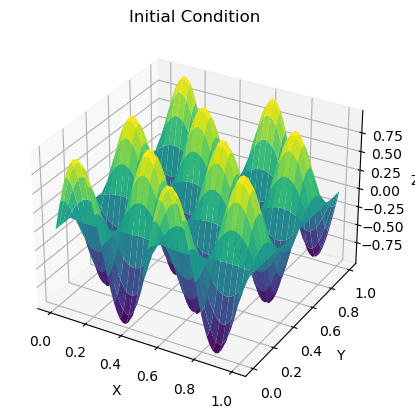

In [3]:
l_x = 1
l_y = 1
n = 64

# %matplotlib qt


x = np.linspace(0, l_x, n)
y = np.linspace(0, l_y, n)

X, Y = np.meshgrid(x, y)

def initial_condition(x, y):
    return np.sin(4 * np.pi * x) * np.cos(4 * np.pi * y)

Z_initial = initial_condition(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z_initial, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Initial Condition')

plt.ion()
plt.show()


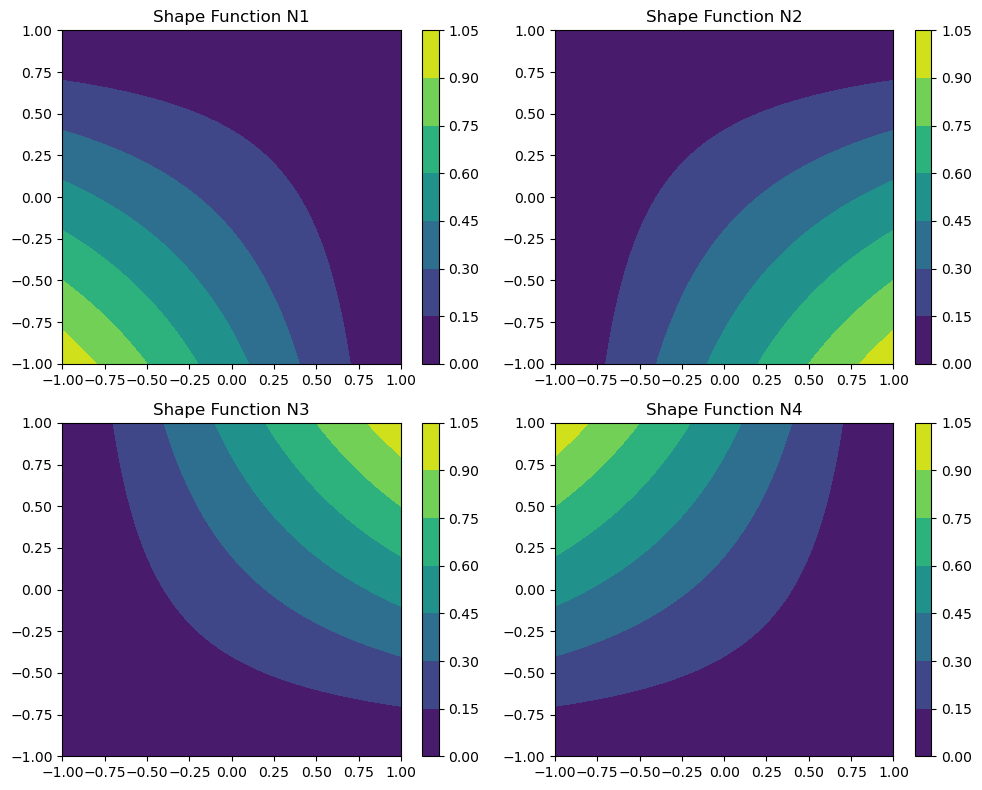

In [4]:
def shape_functions(xi, eta):
    N1 = 0.25 * (1 - xi) * (1 - eta)
    N2 = 0.25 * (1 + xi) * (1 - eta)
    N3 = 0.25 * (1 + xi) * (1 + eta)
    N4 = 0.25 * (1 - xi) * (1 + eta)
    return N1, N2, N3, N4

# Generate grid points for plotting
xi_values = np.linspace(-1, 1, 100)
eta_values = np.linspace(-1, 1, 100)
xi, eta = np.meshgrid(xi_values, eta_values)

# Calculate shape functions at grid points
N1, N2, N3, N4 = shape_functions(xi, eta)

# Plot shape functions
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.contourf(xi, eta, N1, cmap='viridis')
plt.title('Shape Function N1')
plt.colorbar()

plt.subplot(2, 2, 2)
plt.contourf(xi, eta, N2, cmap='viridis')
plt.title('Shape Function N2')
plt.colorbar()

plt.subplot(2, 2, 3)
plt.contourf(xi, eta, N3, cmap='viridis')
plt.title('Shape Function N3')
plt.colorbar()

plt.subplot(2, 2, 4)
plt.contourf(xi, eta, N4, cmap='viridis')
plt.title('Shape Function N4')
plt.colorbar()

plt.tight_layout()
plt.show()


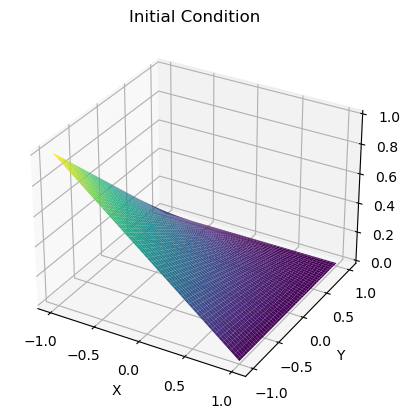

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xi, eta, N1, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Initial Condition')

plt.ion()
plt.show()
